In [3]:
import pandas as pd
# glove_content = pd.read_csv('glove.6B.50d.txt', sep=' ', header=None, quoting=3)

In [5]:
import numpy as np
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

In [6]:
glove2word2vec(r"C:\Users\dai\PycharmProjects\NLP-CV\S07\glove.6B.50d.txt", r"C:\Users\dai\PycharmProjects\NLP-CV\S07\test_wv.txt")

C:\Users\dai\AppData\Local\Temp\ipykernel_8528\33614012.py:1: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(r"C:\Users\dai\PycharmProjects\NLP-CV\S07\glove.6B.50d.txt", r"C:\Users\dai\PycharmProjects\NLP-CV\S07\test_wv.txt")


(400000, 50)

In [7]:
model = KeyedVectors.load_word2vec_format(r"C:\Users\dai\PycharmProjects\NLP-CV\S07\test_wv.txt", binary=False)

In [8]:
model

In [9]:
model.similarity('king', 'queen')

np.float32(0.78390425)

In [10]:
model.similarity('mango', 'apple')

np.float32(0.61270845)

In [11]:
model.similarity('computer', 'woman')

np.float32(0.3295186)

In [13]:
model.similarity('computer', 'keyboard')

np.float32(0.5768126)

In [14]:
model.similarity('king', 'man')

np.float32(0.53093773)

In [15]:
# Analogy: King - Man + Woman = ?

In [16]:
model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)

[('queen', 0.8523604273796082)]

In [21]:
model.most_similar('keyboard')

[('keyboards', 0.853861927986145),
 ('qwerty', 0.826027512550354),
 ('synthesizer', 0.8137233853340149),
 ('accordion', 0.7832949161529541),
 ('guitar', 0.7824674248695374),
 ('synthesizers', 0.7517609000205994),
 ('instrumentation', 0.7388850450515747),
 ('drum', 0.7369818091392517),
 ('strings', 0.7289591431617737),
 ('instrument', 0.7267152070999146)]

In [22]:
model.most_similar('keyboard')[0]

('keyboards', 0.853861927986145)

In [24]:
model.doesnt_match(['mango', 'banana', 'computer'])

'computer'

In [25]:
model.doesnt_match(['mango', 'apple', 'computer'])

'mango'

In [26]:
model.doesnt_match(['mango', 'google', 'apple'])

'mango'

### Visualize

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [29]:
# Reduce the dimensions of these vectors to 2
pca = PCA(n_components=2, random_state=0)

In [41]:
words_of_interest = ['man', 'woman', 'king', 'queen', 'computer', 'keyboard', 'mango', 'apple']

In [42]:
vectors = [model[w] for w in words_of_interest]

In [43]:
vectors = np.array(vectors)

In [44]:
vectors_2d = pca.fit_transform(vectors)

<function matplotlib.pyplot.grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'>

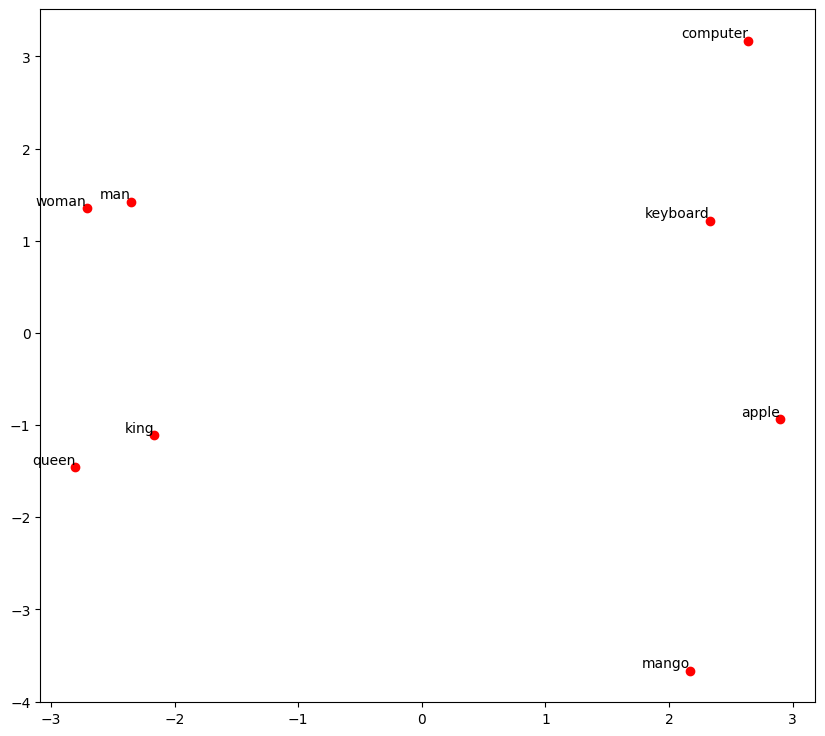

In [45]:
plt.figure(figsize=(10,9))
plt.scatter(vectors_2d[:,0],vectors_2d[:,1], color = 'r')
for i, word in enumerate(words_of_interest):
    plt.annotate(word, (vectors_2d[i,0],vectors_2d[i,1]), ha = 'right', va = 'bottom')
plt.grid